# RVC Weight Difference & Copy (Element-Level)

1. Spočítá rozdíly vah mezi modelem A a B na úrovni jednotlivých elementů
2. Vybere TOP X% elementů s největšími rozdíly (pomocí RATIO)
3. Zkopíruje tyto váhy z modelu A do modelu B

In [190]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import List, Dict, Tuple
import datetime

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.3.1


In [ ]:
# ===== KONFIGURACE =====

# Dva modely pro porovnání
# Váhy se kopírují z A do B
MODEL_A = "Ravdess_F_Angry_60e_1140s.pth"
MODEL_B = "Samuel.pth"

# Poměr vah ke zkopírování (0.0-1.0)
# Např. 0.1 = 10% nejodlišnějších vah, 0.01 = 1%
RATIO = 0.5

# Omezit na konkrétní moduly? (None = všechny)
# Možnosti: "enc_p", "dec", "flow", "emb_g"
MODULES = ["emb_g"]  # nebo např. ["dec", "flow"]

# Výstupní soubor
OUTPUT_PATH = "emb_g_05.pth"

In [192]:
def load_checkpoint(path: str) -> dict:
    """Načte checkpoint z .pth souboru."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model nenalezen: {path}")
    cpt = torch.load(path, map_location="cpu")
    print(f"Načten: {os.path.basename(path)} (SR: {cpt.get('sr')}, v: {cpt.get('version')})")
    return cpt


def extract_weights(cpt: dict) -> OrderedDict:
    """Extrahuje váhy z checkpointu (filtruje enc_q)."""
    weights = cpt.get("model") or cpt.get("weight")
    if weights is None:
        raise ValueError("Neznámý formát checkpointu")
    return OrderedDict((k, v) for k, v in weights.items() if "enc_q" not in k)


def compute_all_differences(
    cpt_a: dict, 
    cpt_b: dict,
    modules: List[str] = None
) -> Tuple[Dict[str, torch.Tensor], Dict[str, dict]]:
    """
    Spočítá rozdíly vah mezi dvěma modely na úrovni elementů.
    
    Returns:
        diff_tensors: Dict {layer_name: abs_diff_tensor}
        stats: Dict {layer_name: {"mean", "max", "numel", "shape"}}
    """
    w_a = extract_weights(cpt_a)
    w_b = extract_weights(cpt_b)
    
    diff_tensors = {}
    stats = {}
    
    for key in w_a.keys():
        # Filtr modulů
        if modules is not None:
            if not any(key.startswith(m) for m in modules):
                continue
        
        if key not in w_b:
            continue
            
        a = w_a[key].float()
        b = w_b[key].float()
        
        if a.shape != b.shape:
            continue
        
        diff = (a - b).abs()
        diff_tensors[key] = diff
        
        stats[key] = {
            "mean": diff.mean().item(),
            "max": diff.max().item(),
            "numel": a.numel(),
            "shape": list(a.shape)
        }
    
    return diff_tensors, stats


def compute_threshold(diff_tensors: Dict[str, torch.Tensor], ratio: float) -> float:
    """
    Spočítá threshold pro výběr TOP ratio% vah.
    """
    # Spojit všechny rozdíly do jednoho vektoru
    all_diffs = torch.cat([d.flatten() for d in diff_tensors.values()])
    total = all_diffs.numel()
    
    # Počet vah k výběru
    k = int(total * ratio)
    k = max(1, min(k, total))  # Alespoň 1, max všechny
    
    # Najít k-tý největší element (threshold)
    threshold = torch.kthvalue(all_diffs, total - k + 1).values.item()
    
    print(f"Celkem parametrů: {total:,}")
    print(f"Ratio: {ratio} -> vybereme {k:,} vah ({100*ratio:.2f}%)")
    print(f"Threshold: {threshold:.8f}")
    
    return threshold


def create_copy_masks(
    diff_tensors: Dict[str, torch.Tensor], 
    threshold: float
) -> Tuple[Dict[str, torch.Tensor], Dict[str, int]]:
    """
    Vytvoří binární masky pro kopírování vah.
    
    Returns:
        masks: Dict {layer_name: bool_tensor} kde True = kopírovat
        counts: Dict {layer_name: počet_vybraných_elementů}
    """
    masks = {}
    counts = {}
    
    for key, diff in diff_tensors.items():
        mask = diff >= threshold
        masks[key] = mask
        counts[key] = mask.sum().item()
    
    total_selected = sum(counts.values())
    print(f"Celkem vybraných vah: {total_selected:,}")
    
    return masks, counts


def apply_mask_copy(
    source_cpt: dict,
    target_cpt: dict,
    masks: Dict[str, torch.Tensor]
) -> OrderedDict:
    """
    Zkopíruje vybrané váhy (podle masek) ze source do target modelu.
    """
    source_weights = extract_weights(source_cpt)
    target_weights = extract_weights(target_cpt)
    
    result = OrderedDict()
    copied_total = 0
    
    for key in target_weights.keys():
        tgt = target_weights[key].float()
        
        if key in masks and key in source_weights:
            src = source_weights[key].float()
            mask = masks[key]
            
            if src.shape == tgt.shape:
                # Použít torch.where pro efektivní kopírování
                result[key] = torch.where(mask, src, tgt)
                copied_total += mask.sum().item()
            else:
                result[key] = tgt
        else:
            result[key] = tgt
    
    print(f"Zkopírováno {copied_total:,} jednotlivých vah")
    return result


def save_model(weights: OrderedDict, base_cpt: dict, output_path: str, info: str = "") -> str:
    """Uloží model."""
    opt = OrderedDict()
    opt["weight"] = OrderedDict((k, v.half()) for k, v in weights.items())
    opt["config"] = base_cpt.get("config")
    opt["sr"] = base_cpt.get("sr")
    opt["f0"] = base_cpt.get("f0", 1)
    opt["version"] = base_cpt.get("version", "v2")
    opt["creation_date"] = datetime.datetime.now().isoformat()
    opt["info"] = info
    
    torch.save(opt, output_path)
    print(f"Uloženo: {output_path} ({os.path.getsize(output_path) / 1024 / 1024:.2f} MB)")
    return output_path


print("Funkce připraveny.")

Funkce připraveny.


In [193]:
# ===== 1. NAČTENÍ MODELŮ =====

cpt_a = load_checkpoint(MODEL_A)
cpt_b = load_checkpoint(MODEL_B)

# ===== 2. VÝPOČET ROZDÍLŮ NA ÚROVNI ELEMENTŮ =====

print("\nPočítám rozdíly vah na úrovni elementů...")
diff_tensors, stats = compute_all_differences(cpt_a, cpt_b, MODULES)
print(f"Analyzováno {len(diff_tensors)} vrstev")

# ===== 3. VÝPOČET THRESHOLD A MASEK =====

print(f"\nVýpočet threshold pro RATIO={RATIO}...")
threshold = compute_threshold(diff_tensors, RATIO)

print("\nVytvářím masky pro kopírování...")
masks, element_counts = create_copy_masks(diff_tensors, threshold)

Načten: Ravdess_F_Angry_60e_1140s.pth (SR: 48000, v: v2)
Načten: Samuel.pth (SR: 48k, v: v2)

Počítám rozdíly vah na úrovni elementů...
Analyzováno 100 vrstev

Výpočet threshold pro RATIO=0.5...
Celkem parametrů: 6,515,328
Ratio: 0.5 -> vybereme 3,257,664 vah (50.00%)
Threshold: 0.00457764

Vytvářím masky pro kopírování...
Celkem vybraných vah: 3,259,001


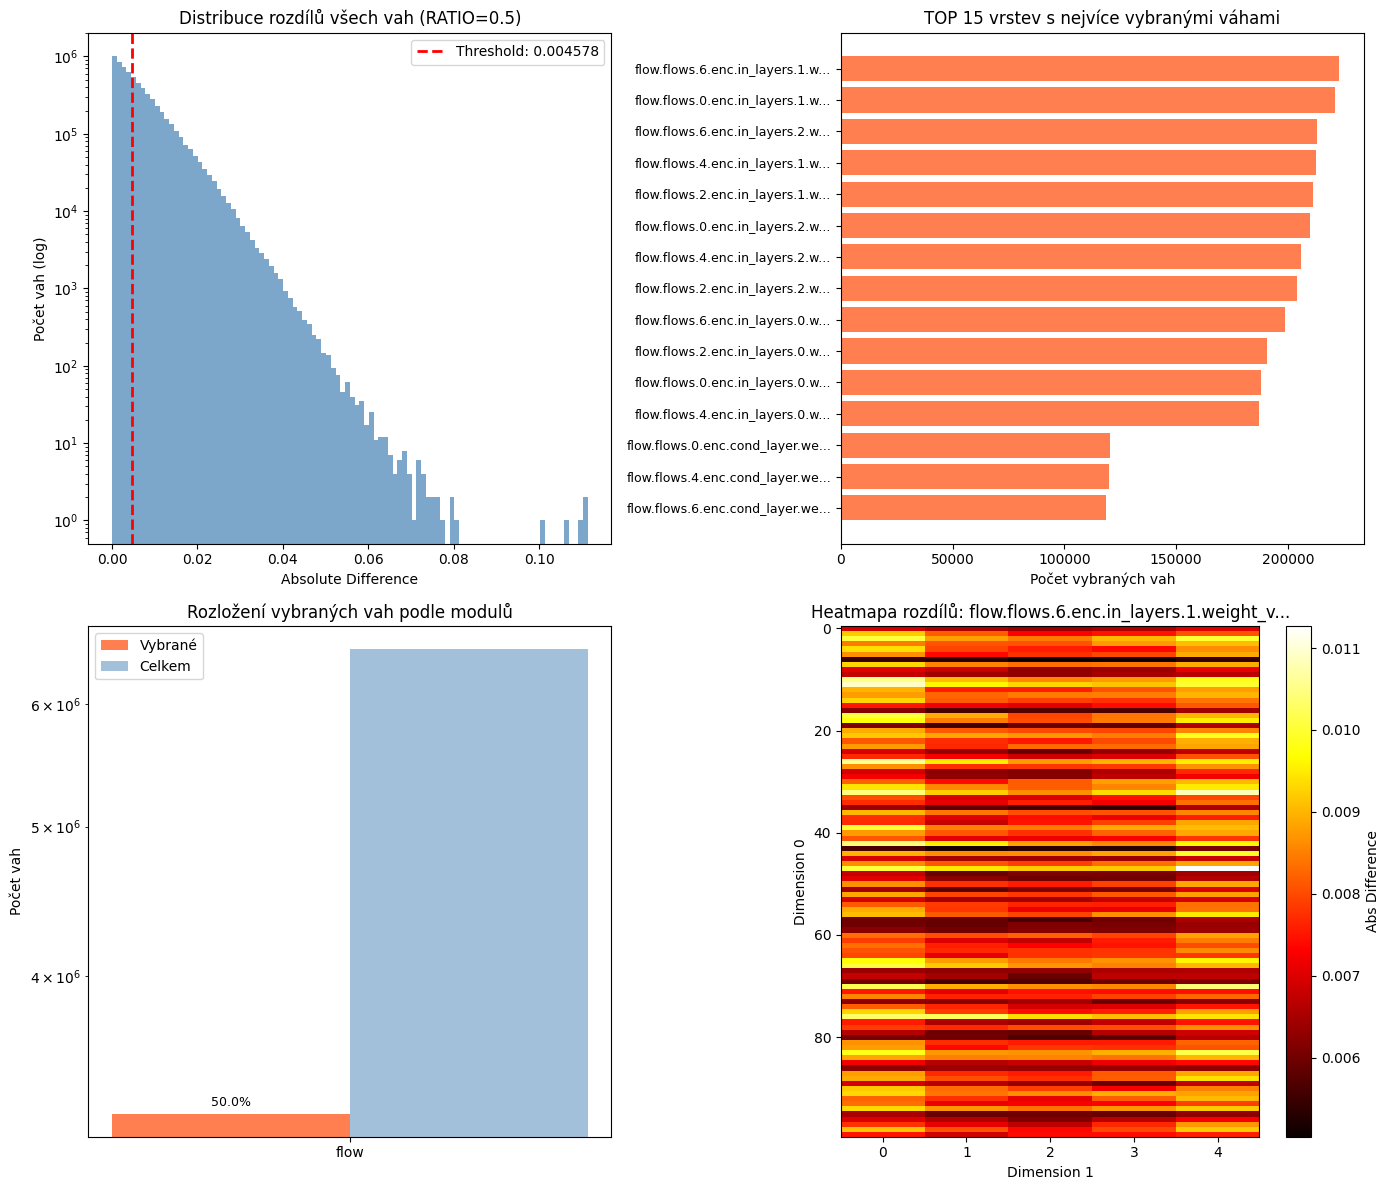


Statistiky:
  Celkem vrstev: 100
  Celkem parametrů: 6,515,328
  Vybraných vah: 3,259,001 (50.00%)
  Threshold: 0.00457764


In [194]:
# ===== VIZUALIZACE =====

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Graf 1: Histogram všech rozdílů ---
ax1 = axes[0, 0]
all_diffs = torch.cat([d.flatten() for d in diff_tensors.values()]).numpy()
ax1.hist(all_diffs, bins=100, color='steelblue', edgecolor='none', alpha=0.7, log=True)
ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:.6f}')
ax1.set_xlabel('Absolute Difference')
ax1.set_ylabel('Počet vah (log)')
ax1.set_title(f'Distribuce rozdílů všech vah (RATIO={RATIO})')
ax1.legend()

# --- Graf 2: TOP vrstvy podle počtu vybraných elementů ---
ax2 = axes[0, 1]
sorted_counts = sorted(element_counts.items(), key=lambda x: x[1], reverse=True)[:15]
layers_short = [l[:30] + "..." if len(l) > 30 else l for l, _ in sorted_counts]
counts_vals = [c for _, c in sorted_counts]
ax2.barh(range(len(layers_short)), counts_vals, color='coral')
ax2.set_yticks(range(len(layers_short)))
ax2.set_yticklabels(layers_short, fontsize=9)
ax2.set_xlabel('Počet vybraných vah')
ax2.set_title('TOP 15 vrstev s nejvíce vybranými váhami')
ax2.invert_yaxis()

# --- Graf 3: Rozložení podle modulů ---
ax3 = axes[1, 0]
module_counts = {"enc_p": 0, "dec": 0, "flow": 0, "emb_g": 0, "other": 0}
module_totals = {"enc_p": 0, "dec": 0, "flow": 0, "emb_g": 0, "other": 0}

for layer, count in element_counts.items():
    matched = False
    for m in ["enc_p", "dec", "flow", "emb_g"]:
        if layer.startswith(m):
            module_counts[m] += count
            module_totals[m] += stats[layer]["numel"]
            matched = True
            break
    if not matched:
        module_counts["other"] += count
        module_totals["other"] += stats[layer]["numel"]

# Pouze moduly s nějakými daty
modules_with_data = [(m, c, module_totals[m]) for m, c in module_counts.items() if module_totals[m] > 0]
mod_names = [m for m, _, _ in modules_with_data]
mod_selected = [c for _, c, _ in modules_with_data]
mod_total = [t for _, _, t in modules_with_data]
mod_pct = [100 * s / t if t > 0 else 0 for s, t in zip(mod_selected, mod_total)]

x = np.arange(len(mod_names))
width = 0.35
bars1 = ax3.bar(x - width/2, mod_selected, width, label='Vybrané', color='coral')
bars2 = ax3.bar(x + width/2, mod_total, width, label='Celkem', color='steelblue', alpha=0.5)
ax3.set_ylabel('Počet vah')
ax3.set_title('Rozložení vybraných vah podle modulů')
ax3.set_xticks(x)
ax3.set_xticklabels(mod_names)
ax3.legend()
ax3.set_yscale('log')

# Přidat procenta nad sloupce
for i, (rect, pct) in enumerate(zip(bars1, mod_pct)):
    ax3.annotate(f'{pct:.1f}%', xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# --- Graf 4: Heatmapa pro vrstvu s nejvíce vybranými váhami ---
ax4 = axes[1, 1]
top_layer = sorted_counts[0][0] if sorted_counts else None
if top_layer and len(diff_tensors[top_layer].shape) >= 2:
    diff_2d = diff_tensors[top_layer]
    # Pokud je víc než 2D, zprůměrovat ostatní dimenze
    while len(diff_2d.shape) > 2:
        diff_2d = diff_2d.mean(dim=0)
    
    # Omezit velikost pro zobrazení
    max_size = 100
    if diff_2d.shape[0] > max_size:
        diff_2d = diff_2d[:max_size, :]
    if diff_2d.shape[1] > max_size:
        diff_2d = diff_2d[:, :max_size]
    
    im = ax4.imshow(diff_2d.numpy(), aspect='auto', cmap='hot')
    plt.colorbar(im, ax=ax4, label='Abs Difference')
    ax4.set_title(f'Heatmapa rozdílů: {top_layer[:40]}...')
    ax4.set_xlabel('Dimension 1')
    ax4.set_ylabel('Dimension 0')
else:
    ax4.text(0.5, 0.5, 'N/A (1D tensor)', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Heatmapa rozdílů')

plt.tight_layout()
plt.show()

# Tabulka statistik
print(f"\nStatistiky:")
print(f"  Celkem vrstev: {len(diff_tensors)}")
print(f"  Celkem parametrů: {sum(s['numel'] for s in stats.values()):,}")
print(f"  Vybraných vah: {sum(element_counts.values()):,} ({100*RATIO:.2f}%)")
print(f"  Threshold: {threshold:.8f}")

In [195]:
# ===== 4. KOPÍROVÁNÍ VAH =====

print(f"Kopíruji vybrané váhy z modelu A do modelu B")
print(f"  Zdroj: {MODEL_A}")
print(f"  Cíl: {MODEL_B}")
print(f"  Počet vah ke zkopírování: {sum(element_counts.values()):,}")

# Kopírování pomocí masek (z A do B)
result_weights = apply_mask_copy(cpt_a, cpt_b, masks)

# Uložení
info = f"Copied {RATIO*100:.1f}% most different weights from {os.path.basename(MODEL_A)} into {os.path.basename(MODEL_B)}"
save_model(result_weights, cpt_b, OUTPUT_PATH, info)

print(f"\nHotovo!")

Kopíruji vybrané váhy z modelu A do modelu B
  Zdroj: Ravdess_F_Angry_60e_1140s.pth
  Cíl: Samuel.pth
  Počet vah ke zkopírování: 3,259,001
Zkopírováno 3,259,001 jednotlivých vah
Uloženo: flow_05.pth (54.91 MB)

Hotovo!


In [196]:
# ===== DETAILNÍ POHLED NA VRSTVY =====

print(f"Vrstvy s nejvíce vybranými váhami:")
print("=" * 80)

sorted_by_count = sorted(element_counts.items(), key=lambda x: x[1], reverse=True)

for i, (layer, count) in enumerate(sorted_by_count[:20], 1):
    total = stats[layer]["numel"]
    pct = 100 * count / total if total > 0 else 0
    print(f"{i:3}. {layer}")
    print(f"     shape: {stats[layer]['shape']}, params: {total:,}")
    print(f"     vybrané váhy: {count:,} ({pct:.2f}%)")
    print(f"     mean diff: {stats[layer]['mean']:.6f}, max diff: {stats[layer]['max']:.6f}")

Vrstvy s nejvíce vybranými váhami:
  1. flow.flows.6.enc.in_layers.1.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 222,959 (60.48%)
     mean diff: 0.007743, max diff: 0.065201
  2. flow.flows.0.enc.in_layers.1.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 221,254 (60.02%)
     mean diff: 0.007699, max diff: 0.064880
  3. flow.flows.6.enc.in_layers.2.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 213,247 (57.85%)
     mean diff: 0.007308, max diff: 0.070557
  4. flow.flows.4.enc.in_layers.1.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 212,650 (57.69%)
     mean diff: 0.007268, max diff: 0.060760
  5. flow.flows.2.enc.in_layers.1.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 211,072 (57.26%)
     mean diff: 0.007251, max diff: 0.064812
  6. flow.flows.0.enc.in_layers.2.weight_v
     shape: [384, 192, 5], params: 368,640
     vybrané váhy: 209,818 (56.92%)
     mea